# POC 02 (v4) — orientation, local vs global, window reconstruction

**What v4 adds to v3:**

| § | new |
|---|---|
| 1c | **flow orientation** per sensor (sign, reversals) and the **channel-alignment** table |
| 2 | grid: every loss setting × `orient ∈ {False, True}`, plus stride 4 (the geometry of POC_03's centralised ceiling) |
| 3 | local vs global columns in the sanity table, and the orientation effect per client |
| 5 | **local vs global**: per-client gap, cross-client model matrix, per-window views of local models |

**Why these two.** POC_03 showed the AER reconstructs single clients almost exactly
(pure r ≈ 0.99), so the FL shortfall is the step budget plus FedAvg conflict. v3's run files
show flow signs that differ by pipe orientation:
* A's pure channels are negative, D's are positive;
* B's and C's pure pairs have opposite signs;
* several mixed sensors reverse direction.

B's pure channels were anti-correlated under the global model.

**Local weights are new in saved runs** (`meta.client_weights`). Runs from v3 do not have
them, so the training cell retrains any cell that lacks them (`REFRESH_NO_LOCAL`).
**Restart the kernel** before running.

In [1]:
import torch
print(torch.__version__, torch.version.cuda, torch.cuda.is_available())

2.5.1+cu124 12.4 True


## 0. Setup

In [2]:
import sys, pathlib, time
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

REQUIRE_GPU = True
if REQUIRE_GPU:
    assert torch.cuda.is_available(), (
        f"no CUDA device (torch {torch.__version__}, cuda {torch.version.cuda})")
    
REPO = next((p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
             if (p / "src" / "fedwater").is_dir()), None)
assert REPO is not None, "run this from inside the fedwater repo"
LAB_DIR = REPO / "notebooks" / "fedwater_lab_refactor"
for p in (REPO / "src", LAB_DIR):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

from fedwater_lab.worlds import load_world, list_worlds, pick_world
from fedwater_lab.store import Store
from fedwater_lab.specs import POC, Geometry, LossTerms
from fedwater_lab.runner import run_cell
from fedwater_lab import data as D, recon as RC, train as T
from fedwater_lab import aligned as AL, winrec as WR, localeval as LE

EXPERIMENTS = REPO / "data" / "09_experiments"
pd.set_option("display.width", 220, "display.max_columns", 40)

## 1. World and sensors

The selection is the same as POC_01 / the first POC_02 run, so the `base` cell below is a
cache read of that run.

In [3]:
FILTERS = dict(sim_hash="ece8f4ad92e5", placement_source="dynamic")
world = load_world(pick_world(EXPERIMENTS, **FILTERS))
store = Store(LAB_DIR / "lab_sandbox")
print(world.summary().to_string())

SELECTION = dict(kinds=("flow",), classes=("pure", "mixed"), include=(), exclude=())
BASE = POC.with_(**SELECTION)

kept = D.sensor_table(world, BASE)
why = ["district", "slot", "slot_class", "sensor", "tier", "purity", "second", "w_second"]
display(kept[[c for c in why if c in kept.columns]].round(3))

sim_hash                                 ece8f4ad92e5
tag                 District_A__LR_LR_LR_LR__baseline
network                                          ky72
districting                                  spectral
partition_id                                 29fddafe
placement_source                              dynamic
n_months                                           65
resolution_h                                        1
steps_day                                          24
clients                                             4
n_sensors                                          32
n_pure                                             16
n_mixed                                            16
drift_district                             District_A
warmup_months                                      12
first_switch                                       12
last_switch                                        63
ramp_days                                         7.0
init_months                 

,district,slot,slot_class,sensor,tier,purity,second,w_second
0,District_A,q_mixed_0,mixed,q_P-558,foreign,0.000,District_B,0.725
1,District_A,q_mixed_1,mixed,q_P-10,transition,0.272,District_D,0.728
2,District_A,q_pure_0,pure,q_P-42,core,1.000,NaN,0.000
3,District_A,q_pure_1,pure,q_P-556,core,1.000,NaN,0.000
4,District_B,q_mixed_0,mixed,q_P-605,foreign,0.000,District_A,0.656
5,District_B,q_mixed_1,mixed,q_P-588,transition,0.477,District_C,0.263
6,District_B,q_pure_0,pure,q_P-30,core,1.000,NaN,0.000
7,District_B,q_pure_1,pure,q_P-285,core,1.000,NaN,0.000
8,District_C,q_mixed_0,mixed,q_P-518,transition,0.437,District_B,0.290
9,District_C,q_mixed_1,mixed,q_P-521,transition,0.254,District_B,0.378


### 1b. Store audit

For every saved run of this world, the audit compares `spec.json` (what the run key says)
with `fl.json` (what actually trained). Rows with `ok = False` were saved under the caching
bug and **must be purged** before §2, otherwise they are served as cache hits. Set
`PURGE = True` to delete exactly those rows.

In [4]:
AUDIT = store.audit(world.sim_hash)
display(AUDIT[["run_key", "label", "rounds_spec", "rounds_fl", "epochs_spec", "epochs_fl",
               "ok", "mismatch"]])

PURGE = False
bad = AUDIT.loc[~AUDIT["ok"], "run_key"].tolist()
if PURGE and bad:
    print("purged:", store.purge(world.sim_hash, bad))
    display(store.audit(world.sim_hash)[["run_key", "label", "ok"]])
elif bad:
    print(f"{len(bad)} run(s) disagree with their spec -- set PURGE = True to remove them")

,run_key,label,rounds_spec,rounds_fl,epochs_spec,epochs_fl,ok,mismatch
0,028ca9bf44b3,fmp__none__minmax_ref__a3w84s12__u30r30e5s0__L...,30,30,5,5,True,
1,24403632d296,fmp__none__minmax_ref__a3w84s12__u30r30e5pw0s0,30,30,5,5,True,
2,3675c1f38427,fmp__none__minmax_ref__a3w84s12__u30r5s0,5,5,1,1,True,
3,79139ce2449a,fmp__none__minmax_ref__a3w84s12__u30r30e5s0__Lv1,30,30,5,5,True,
4,91e9ca3d8e16,fmp__none__minmax_ref__a3w84s12__u30r30e5s0__Lp0,30,30,5,5,True,
5,949895d5bea0,fmp__none__minmax_ref__a3w84s12__u30r30e5s0__L...,30,30,5,5,True,
6,ebf14537cde1,fmp__none__minmax_ref__a3w84s12__u30r30e5s0,30,30,5,5,True,


### 1c. Flow orientation and channel alignment

The table below is computed on the raw frames, per sensor, over the reference months:

* `sign` $=\mathrm{sign}(\mathrm{median})$;
* `frac_rev_ref` and `frac_rev_all` are the shares of steps against that sign, over the
  reference months and over the whole series;
* `bidirectional` flags a sensor with more than 5% reversed steps in either period.

`orient=True` multiplies each slot by its `sign`. This is a fixed, client-side, per-sensor
convention, like an installation direction, applied before the transform and the scaler.
For bidirectional sensors a flip does not make them one-directional: the sign itself carries
the supply direction.

**Channel alignment.** Channels are ordered by slot name in every client, so channel $i$ is
the same *slot* everywhere by construction. The alignment table shows what that does not fix:
the sensor's tier, purity, secondary district, sign and reversals.

In [5]:
OT = D.orientation_table(world, BASE)
display(OT[["client", "slot", "sensor", "tier", "purity", "second", "median_ref", "sign",
            "frac_rev_ref", "frac_rev_all", "bidirectional"]].round(3))
display(D.channel_alignment(world, BASE))

,client,slot,sensor,tier,purity,second,median_ref,sign,frac_rev_ref,frac_rev_all,bidirectional
0,District_A,q_mixed_0,q_P-558,foreign,0.000,District_B,-0.169,-1.0,0.448,0.377,True
1,District_A,q_mixed_1,q_P-10,transition,0.272,District_D,-0.878,-1.0,0.434,0.396,True
2,District_A,q_pure_0,q_P-42,core,1.000,NaN,-0.180,-1.0,0.000,0.000,False
3,District_A,q_pure_1,q_P-556,core,1.000,NaN,-0.448,-1.0,0.000,0.000,False
4,District_B,q_mixed_0,q_P-605,foreign,0.000,District_A,0.069,1.0,0.479,0.606,True
5,District_B,q_mixed_1,q_P-588,transition,0.477,District_C,0.183,1.0,0.438,0.298,True
6,District_B,q_pure_0,q_P-30,core,1.000,NaN,0.478,1.0,0.000,0.000,False
7,District_B,q_pure_1,q_P-285,core,1.000,NaN,-0.339,-1.0,0.000,0.000,False
8,District_C,q_mixed_0,q_P-518,transition,0.437,District_B,0.329,1.0,0.000,0.000,False
9,District_C,q_mixed_1,q_P-521,transition,0.254,District_B,1.167,1.0,0.000,0.000,False


client,District_A,District_B,District_C,District_D
channel,,,,
0,q_mixed_0 · foreign · p0.00 · +District_B · - ...,q_mixed_0 · foreign · p0.00 · +District_A · + ...,q_mixed_0 · transition · p0.44 · +District_B · +,q_mixed_0 · core · p1.00 · +
1,q_mixed_1 · transition · p0.27 · +District_D ·...,q_mixed_1 · transition · p0.48 · +District_C ·...,q_mixed_1 · transition · p0.25 · +District_B · +,q_mixed_1 · core · p1.00 · +
2,q_pure_0 · core · p1.00 · -,q_pure_0 · core · p1.00 · +,q_pure_0 · core · p1.00 · -,q_pure_0 · core · p1.00 · +
3,q_pure_1 · core · p1.00 · -,q_pure_1 · core · p1.00 · -,q_pure_1 · core · p1.00 · +,q_pure_1 · core · p1.00 · +


## 2. Training grid

Three objectives from v3, each with and without orientation, at the v3 geometry (`a3w84s12`),
30 rounds × 5 local epochs:

| key | objective |
|---|---|
| `long` | upstream: `aer_loss + proto_loss` |
| `pw0` | reconstruction only, `LossTerms(proto_weight=0)` |
| `pw.1+d` | `LossTerms(proto_weight=0.1, diff=1)` |
| `pw.1+s` | `LossTerms(proto_weight=0.1, spec=1)` |

Two more cells run `pw0` at **stride 4**. That is POC_03's ceiling geometry, with about 3× the
windows, so about 3× the steps and about 3× the time per cell.

`REFRESH_NO_LOCAL = True` retrains a stored cell that has no local weights. That covers every
v3 cell, and each costs a full training.

The lab loop was verified bit-identical to upstream in v3 (§2a there). Set `RUN_EQUIV` to
repeat the check.

In [6]:
LONG = {"training.rounds": 30, "training.local_epochs": 5}
L_P0 = LossTerms(proto_weight=0.0)
L_D = LossTerms(proto_weight=0.1, diff=1.0)
L_S = LossTerms(proto_weight=0.1, spec=1.0)
S4 = Geometry(interval_agg_h=3, window_size=84, step_size=4)

CELLS = {}
for name, kw in {"long":   dict(),
                 "pw0":    dict(loss_terms=L_P0),
                 "pw.1+d": dict(loss_terms=L_D),
                 "pw.1+s": dict(loss_terms=L_S),
                 "pw0·s4": dict(loss_terms=L_P0, geometry=S4)}.items():
    CELLS[name] = BASE.with_(**LONG, **kw)
    CELLS[name + "·or"] = BASE.with_(**LONG, **kw, orient=True)

TRAIN = list(CELLS)
REFRESH_NO_LOCAL = True
display(pd.DataFrame([{"cell": k, "label": s.label(), "in store": store.exists(world, s)}
                      for k, s in CELLS.items()]))

,cell,label,in store
0,long,fmp__none__minmax_ref__a3w84s12__u30r30e5s0,True
1,long·or,fmp__none+or__minmax_ref__a3w84s12__u30r30e5s0,False
2,pw0,fmp__none__minmax_ref__a3w84s12__u30r30e5s0__Lp0,True
3,pw0·or,fmp__none+or__minmax_ref__a3w84s12__u30r30e5s0...,False
4,pw.1+d,fmp__none__minmax_ref__a3w84s12__u30r30e5s0__L...,True
5,pw.1+d·or,fmp__none+or__minmax_ref__a3w84s12__u30r30e5s0...,False
6,pw.1+s,fmp__none__minmax_ref__a3w84s12__u30r30e5s0__L...,True
7,pw.1+s·or,fmp__none+or__minmax_ref__a3w84s12__u30r30e5s0...,False
8,pw0·s4,fmp__none__minmax_ref__a3w84s4__u30r30e5s0__Lp0,False
9,pw0·s4·or,fmp__none+or__minmax_ref__a3w84s4__u30r30e5s0_...,False


In [7]:
RUN_EQUIV = False
if RUN_EQUIV:
    fw0, _, fl0 = D.build_windows(world, BASE, cache=D.CACHE)
    EQ = T.equivalence_check(fw0, fl0, seed=0, rounds=2)
    display(EQ)
    assert EQ["identical"].all()

In [8]:
RUNS = {}
for name in TRAIN:
    spec = CELLS[name]
    t0 = time.time()
    try:
        res = run_cell(world, spec, store=store, verbose=False)
        if REFRESH_NO_LOCAL and res["meta"].get("client_weights") != "local_pre_fedavg":
            print(f"{name:<14} no local weights -> retraining")
            res = run_cell(world, spec, store=store, verbose=False, overwrite=True)
    except RuntimeError as exc:
        print(f"{name:<14} REFUSED: {exc}")
        continue
    bad = T.fl_mismatches(spec, res["fl"])
    if bad:
        raise AssertionError(f"{name}: stored run trained with {bad} -- purge it (§1b)")
    RUNS[name] = res["run_key"]
    print(f"{name:<14} {res['run_key']}  cache_hit={res['cache_hit']}  "
          f"local={res['meta'].get('client_weights')}  {time.time() - t0:.0f}s")

long           no local weights -> retraining
long           ebf14537cde1  cache_hit=False  local=local_pre_fedavg  231s
long·or        5da9df16294e  cache_hit=False  local=local_pre_fedavg  272s
pw0            no local weights -> retraining
pw0            91e9ca3d8e16  cache_hit=False  local=local_pre_fedavg  247s
pw0·or         274f83bbaa3a  cache_hit=False  local=local_pre_fedavg  249s
pw.1+d         no local weights -> retraining
pw.1+d         028ca9bf44b3  cache_hit=False  local=local_pre_fedavg  278s
pw.1+d·or      234dfe52877b  cache_hit=False  local=local_pre_fedavg  287s
pw.1+s         no local weights -> retraining
pw.1+s         949895d5bea0  cache_hit=False  local=local_pre_fedavg  291s
pw.1+s·or      69c7fe1265bf  cache_hit=False  local=local_pre_fedavg  292s
pw0·s4         0f14e551356d  cache_hit=False  local=local_pre_fedavg  735s
pw0·s4·or      834f3f95df95  cache_hit=False  local=local_pre_fedavg  750s


## 3. Sanity, per cell

Each cell is decoded and checked against the **untrained control**. That is the round −1
model, rebuilt from the seed and asserted equal to the saved round −1 snapshot, and it is
applied to every window.

| column | meaning |
|---|---|
| `steps/client` | rounds × local epochs × batches |
| `d_mse_last` | relative change of `loss_mse` at the last round; < 0 means still learning |
| `aux_share` | $1 -$ `loss_mse` / `loss`, last round: the weighted share of the objective that is not reconstruction |
| `final_over_wmean` | final AER loss / best flat line (each window's own mean); < 1 means shape is captured |
| `window_amp`, `window_r` | median $\sigma_t(\hat x)/\sigma_t(x)$ and $\mathrm{corr}_t(\hat x, x)$ per window |
| `level_r` | $\mathrm{corr}_w$ of window means, decoded vs true |
| `eta_lift_final` / `_ctrl` | §4 η² lift (time-of-day key), trained vs untrained, all windows |
| `rel_block_first/last` | within-month latent spread / latent norm, first and last snapshot |
| `ctrl_window_amp` | the same amplitude score for the untrained model |

Local vs global, over every client's own windows (in-sample, see `localeval`):
`global_ratio` / `local_ratio` are the loss divided by the best flat line, `global_r` /
`local_r` the median window correlation, and `cross_r` is a client's local model applied to
the *other* clients' windows.

This takes about a minute per cell (decoding, permutations, control). `sanity` raises if a run's
saved `fl` or its log length disagrees with the spec.

,long,long·or,pw0,pw0·or,pw.1+d,pw.1+d·or,pw.1+s,pw.1+s·or,pw0·s4,pw0·s4·or
label,fmp__none__minmax_ref__a3w84s12__u30r30e5s0,fmp__none+or__minmax_ref__a3w84s12__u30r30e5s0,fmp__none__minmax_ref__a3w84s12__u30r30e5s0__Lp0,fmp__none+or__minmax_ref__a3w84s12__u30r30e5s0...,fmp__none__minmax_ref__a3w84s12__u30r30e5s0__L...,fmp__none+or__minmax_ref__a3w84s12__u30r30e5s0...,fmp__none__minmax_ref__a3w84s12__u30r30e5s0__L...,fmp__none+or__minmax_ref__a3w84s12__u30r30e5s0...,fmp__none__minmax_ref__a3w84s4__u30r30e5s0__Lp0,fmp__none+or__minmax_ref__a3w84s4__u30r30e5s0_...
run_key,ebf14537cde1,5da9df16294e,91e9ca3d8e16,274f83bbaa3a,028ca9bf44b3,234dfe52877b,949895d5bea0,69c7fe1265bf,0f14e551356d,834f3f95df95
steps/client,1050,1050,1050,1050,1050,1050,1050,1050,2850,2850
loss_mse_last,0.23265,0.142542,0.218852,0.122734,0.179462,0.144148,0.198226,0.116368,0.106033,0.07175
d_mse_last,-0.032449,-0.012069,0.003687,-0.015977,-0.027257,-0.006241,-0.046686,-0.05025,-0.013213,0.096963
aux_share,0.75707,0.832941,0.0,0.0,0.611867,0.622905,0.432961,0.536079,0.0,0.0
final_over_wmean,0.999462,0.632495,0.800147,0.531624,0.998987,0.60719,1.074288,0.605212,0.568115,0.457274
final_over_const,0.892439,0.538727,0.707711,0.468371,0.888,0.524082,0.973095,0.522923,0.497784,0.395791
window_amp,0.098313,0.659004,0.103428,0.665652,0.145079,0.60006,0.661868,0.833537,0.400838,0.754733
window_r,0.029138,0.61549,0.11491,0.616113,0.249159,0.616643,0.26125,0.737762,0.524028,0.731103


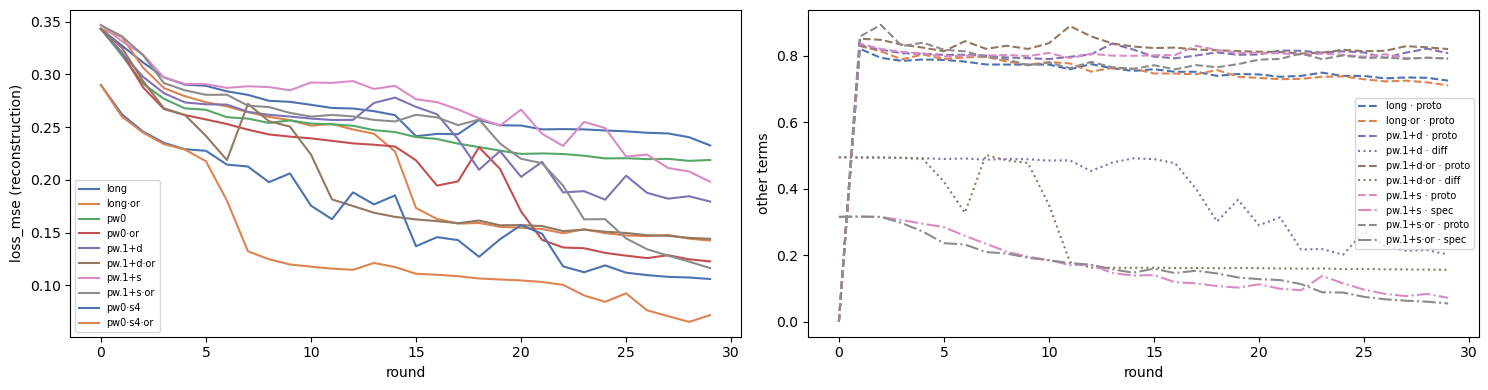

In [9]:
ALIGN24 = AL.Alignment(period_h=24, bin_h=None, block=1)
OUTS, SAN = {}, {}
for name in RUNS:
    OUTS[name] = AL.analyse(world, CELLS[name], ALIGN24, store=store, server=False, n_perm=99)
    SAN[name] = AL.sanity(world, OUTS[name], n_perm=99)
    assert OUTS[name]["checks"]["passed"].all(), OUTS[name]["checks"]
    assert SAN[name]["control_check"]["passed"].all(), SAN[name]["control_check"]

MM = {}
for name in RUNS:
    ch = RC.channel_table(world, OUTS[name]["fw"])
    MM[name] = LE.model_matrix(world, OUTS[name], ch, store=store)
    SAN[name]["row"] = pd.concat([SAN[name]["row"], pd.Series(LE.lg_row(MM[name]))])

SANITY = pd.DataFrame({k: v["row"] for k, v in SAN.items()})
display(SANITY)

fig, ax = plt.subplots(1, 2, figsize=(15, 4))
AL.plot_losses(ax, {k: OUTS[k]["res"]["training_log"] for k in OUTS})
fig.tight_layout()
plt.show()

### 3b. Orientation effect, per client

For each objective, the table compares each client with raw signs and with orientation.
It shows global and local `r` on the client's own windows (pure and mixed), and `r_cross`,
the other clients' local models on these windows. If sign conflict explains the v3 results:
* `r_pure_global` rises for the clients whose pure pair had mixed signs (B, C), and does not
  change for D;
* the local-minus-global gap shrinks;
* `r_cross` rises.

In [10]:
rows = []
for base in ("long", "pw0", "pw.1+d", "pw.1+s", "pw0·s4"):
    for tag, name in (("raw", base), ("or", base + "·or")):
        if name not in MM:
            continue
        g = LE.gap_table(MM[name]).set_index("client")
        for c, r in g.iterrows():
            rows.append({"objective": base, "orient": tag, "client": c,
                         "r_pure_global": r["r_pure_global"], "r_mixed_global": r["r_mixed_global"],
                         "r_global": r["r_global"], "r_local": r["r_local"],
                         "r_gap": r["r_gap"], "r_cross": r["r_cross"],
                         "ratio_global": r["ratio_global"], "ratio_local": r["ratio_local"]})
EFFECT = pd.DataFrame(rows)
display(EFFECT.pivot_table(index=["objective", "client"], columns="orient",
                           values=["r_pure_global", "r_mixed_global", "r_gap", "r_cross",
                                   "ratio_global"]).round(3))

r_cross         r_gap        r_mixed_global        r_pure_global        ratio_global       
orient                    or    raw     or    raw             or    raw            or    raw           or    raw
objective client                                                                                                
long      District_A   0.241 -0.035  0.005  0.103          0.221  0.004         0.251  0.015        0.837  0.934
          District_B   0.736 -0.052 -0.016  0.177          0.031  0.042         0.867 -0.105        0.612  1.111
          District_C   0.481 -0.003 -0.003  0.114          0.067  0.034         0.866  0.224        0.762  1.035
          District_D   0.850  0.015  0.010  0.744          0.845  0.071         0.868  0.125        0.320  0.918
pw.1+d    District_A   0.194 -0.145 -0.027  0.385          0.266  0.111         0.238  0.058        0.733  0.987
          District_B   0.738 -0.195 -0.000  0.302          0.047  0.420         0.870  0.457        0.633  1.125
          District_C   0.572 -0.157  0.021  0.347          0.076  0.125         0.870  0.763        0.752  0.906
          District_D   0.861 -0.063  0.002  0.902          0.866  0.405         0.873 -0.148        0.311  0.978
pw.1+s    District_A   0.556  0.080  0.134  0.330          0.561  0.254         0.714  0.264        0.721  0.868
          District_B   0.810 -0.091  0.065  0.551          0.396  0.132         0.904  0.156        0.556  1.337
          District_C   0.473  0.009  0.127  0.464          0.139  0.153         0.901 -0.013        0.801  1.106
          District_D   0.738  0.150  0.008  0.274          0.753  0.497         0.903  0.658        0.344  0.987
pw0       District_A   0.190  0.088  0.010  0.032          0.195  0.067         0.227  0.161        0.550  0.815
          District_B   0.729  0.093 -0.008  0.027          0.076  0.072         0.867  0.148        0.650  0.786
          District_C   0.498  0.062  0.055  0.080          0.100  0.022         0.868  0.188        0.635  0.830
          District_D   0.850  0.048  0.001  0.125          0.870  0.200         0.869  0.107        0.291  0.769
pw0·s4    District_A   0.396  0.003  0.348  0.270          0.386  0.195         0.596  0.178        0.541  0.624
          District_B   0.856  0.303  0.043  0.053          0.444  0.422         0.934  0.832        0.486  0.531
          District_C   0.612  0.123  0.150  0.251          0.251  0.155         0.932  0.845        0.572  0.603
          District_D   0.812  0.087  0.015  0.127          0.881  0.761         0.937  0.628        0.230  0.514

## 4. Focus cell

Everything below reads one cell. The objects are:
* `run`: the global model on every window, keyed by time of day.
* `LOCAL[c]`: client c's local model on its own windows.
* `ctrl`: the untrained model on every window.
* `channels`: slot, class and mixture label of each channel.

In [21]:
FOCUS = "long·or" #"pw.1+s·or"                # any key of OUTS
out, san = OUTS[FOCUS], SAN[FOCUS]
run, ctrl, fw, model = out["run"], san["control"], out["fw"], out["model"]
spec_f = CELLS[FOCUS]
channels = RC.channel_table(world, fw)
mm = MM[FOCUS]
LOCAL = LE.local_runs(world, out, store=store)         # {client: AlignedRun, local model}
print(spec_f.label())
display(channels)

fmp__none+or__minmax_ref__a3w84s12__u30r30e5s0


,client,channel,slot,sensor,kind,slot_class,w_District_A,w_District_B,w_District_C,w_District_D
0,District_A,0,q_mixed_0,q_P-558,flow,mixed,0.000000,0.724639,0.275361,0.000000
1,District_A,1,q_mixed_1,q_P-10,flow,mixed,0.272429,0.000000,0.000000,0.727571
2,District_A,2,q_pure_0,q_P-42,flow,pure,1.000000,0.000000,0.000000,0.000000
3,District_A,3,q_pure_1,q_P-556,flow,pure,1.000000,0.000000,0.000000,0.000000
4,District_B,0,q_mixed_0,q_P-605,flow,mixed,0.656441,0.000000,0.343559,0.000000
5,District_B,1,q_mixed_1,q_P-588,flow,mixed,0.259996,0.476966,0.263038,0.000000
6,District_B,2,q_pure_0,q_P-30,flow,pure,0.000000,1.000000,0.000000,0.000000
7,District_B,3,q_pure_1,q_P-285,flow,pure,0.000000,1.000000,0.000000,0.000000
8,District_C,0,q_mixed_0,q_P-518,flow,mixed,0.272517,0.290256,0.437227,0.000000
9,District_C,1,q_mixed_1,q_P-521,flow,mixed,0.368882,0.377574,0.253544,0.000000


## 5. Local vs global, and window reconstruction

**5a. What averaging costs.** For each client:
* **global** is the FedAvg model on its windows;
* **local** is its own pre-FedAvg model;
* **cross** is the mean of the other clients' local models.

In the matrices, rows are models and columns are the client whose windows are reconstructed.
A column that only its own local model reconstructs is a client whose channels behave
differently from the others'.

client,District_A,District_B,District_C,District_D
ratio_global,0.837,0.612,0.762,0.320
ratio_local,0.556,0.429,0.581,0.171
ratio_cross,1.271,0.867,1.024,0.430
amp_global,0.261,0.756,0.732,0.651
amp_local,0.278,0.699,0.429,0.922
amp_cross,0.406,0.740,0.747,0.606
r_global,0.241,0.747,0.572,0.857
r_local,0.246,0.731,0.570,0.868
r_cross,0.241,0.736,0.481,0.850
r_pure_global,0.251,0.867,0.866,0.868


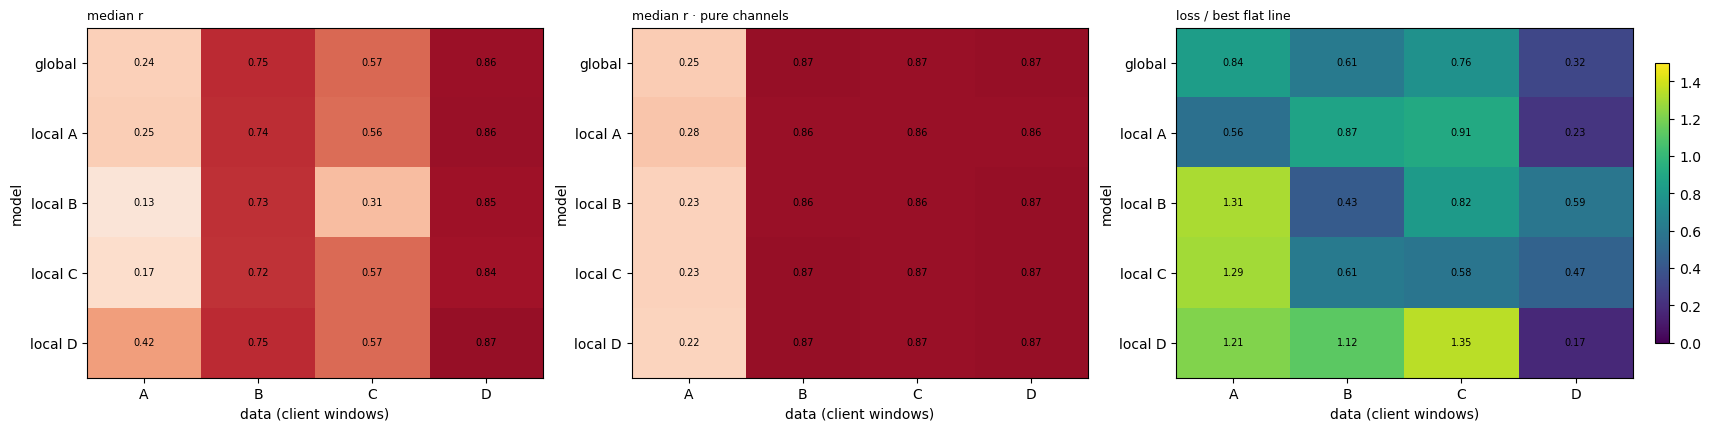

In [22]:
display(LE.gap_table(mm).set_index("client").round(3).T)
fig, axes = plt.subplots(1, 3, figsize=(17, 4.2), layout="constrained")
LE.plot_matrix(axes[0], mm, "r", title="median r")
LE.plot_matrix(axes[1], mm, "r_pure", title="median r · pure channels")
im = LE.plot_matrix(axes[2], mm, "ratio", vmin=0, vmax=1.5, cmap="viridis",
                    title="loss / best flat line")
fig.colorbar(im, ax=axes[2], shrink=0.8)
plt.show()

**5b. Per-window scores.** Each window and channel gets:
* `rmse` $=\sqrt{\mathrm{mean}_t(\hat x - x)^2}$
* `r` $=\mathrm{corr}_t(\hat x, x)$
* `amp` $=\sigma_t\hat x / \sigma_t x$
* `lvl` $=\overline{\hat x} - \bar x$

The table gives medians per client × slot class for the global, local and untrained models.
The grids show global `r` over month × start class, with weekday = day mod 7 from step 0.
The position profiles give, for each position $t$ in the window,
$\mathrm{corr}_w(\hat x_w[t], x_w[t])$, global on top and local below.

global                local               untrained              
                           r    amp   rmse      r    amp   rmse         r    amp   rmse
client     slot_class                                                                  
District_A mixed       0.221  0.196  0.459  0.170  0.205  0.459    -0.007  0.001  0.524
           pure        0.251  0.413  0.594  0.277  0.302  0.455    -0.071  0.004  0.904
District_B mixed       0.031  0.376  0.533  0.480  0.550  0.499     0.068  0.001  0.575
           pure        0.867  0.968  0.296  0.865  0.930  0.298    -0.050  0.002  0.598
District_C mixed       0.067  0.380  0.660  0.111  0.164  0.586     0.043  0.001  0.678
           pure        0.866  0.924  0.299  0.867  0.885  0.299    -0.014  0.003  0.601
District_D mixed       0.845  0.398  0.446  0.865  0.830  0.316     0.012  0.001  0.606
           pure        0.868  0.918  0.305  0.870  0.931  0.301    -0.023  0.003  0.619

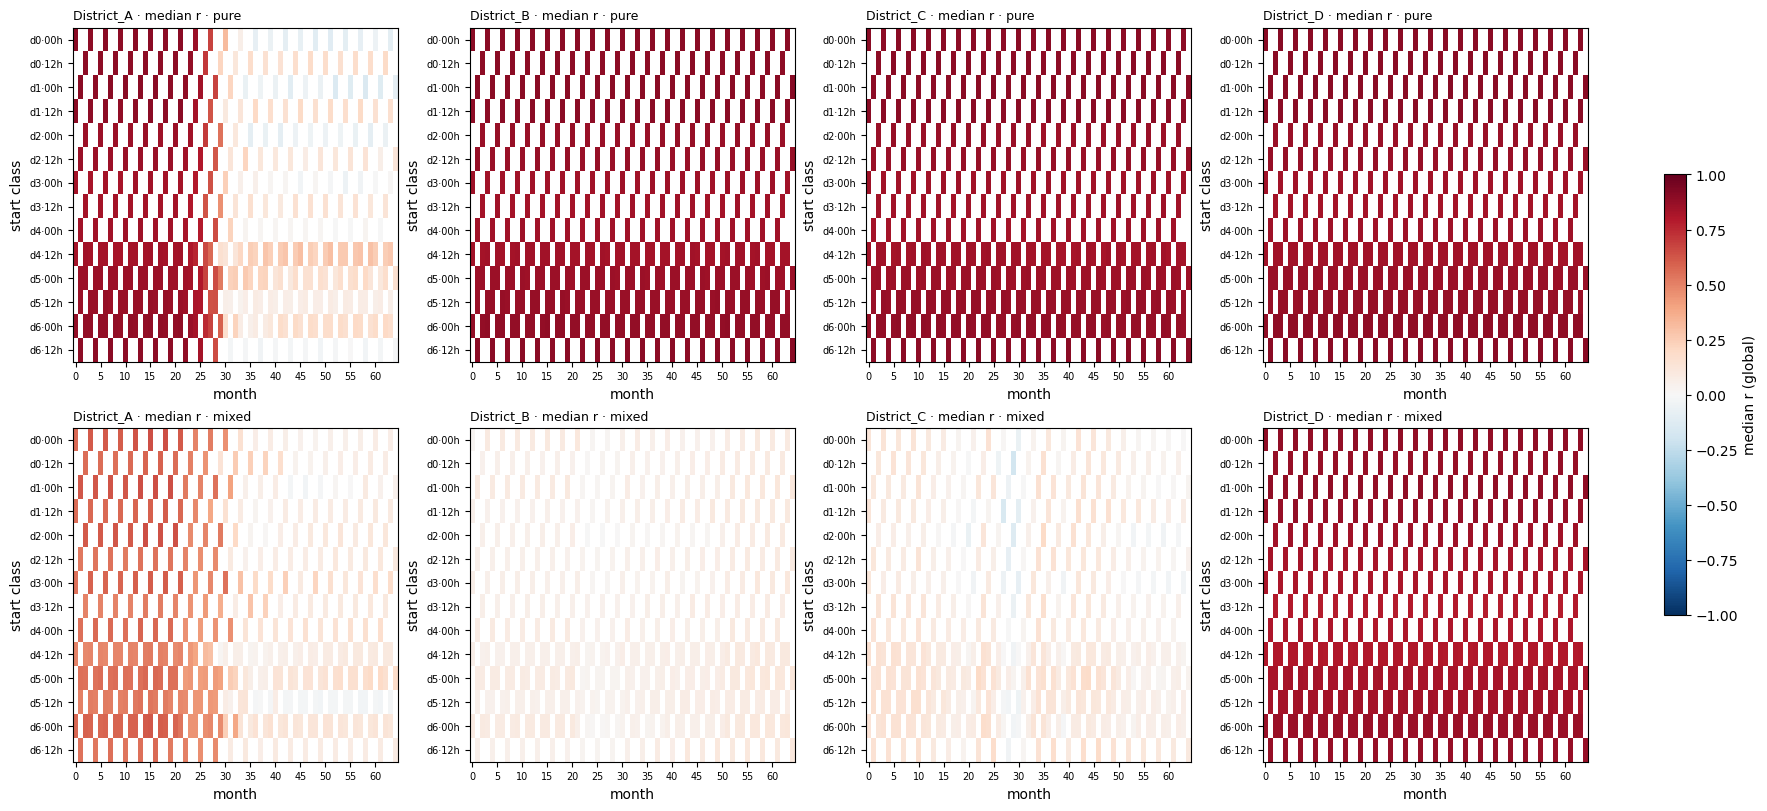

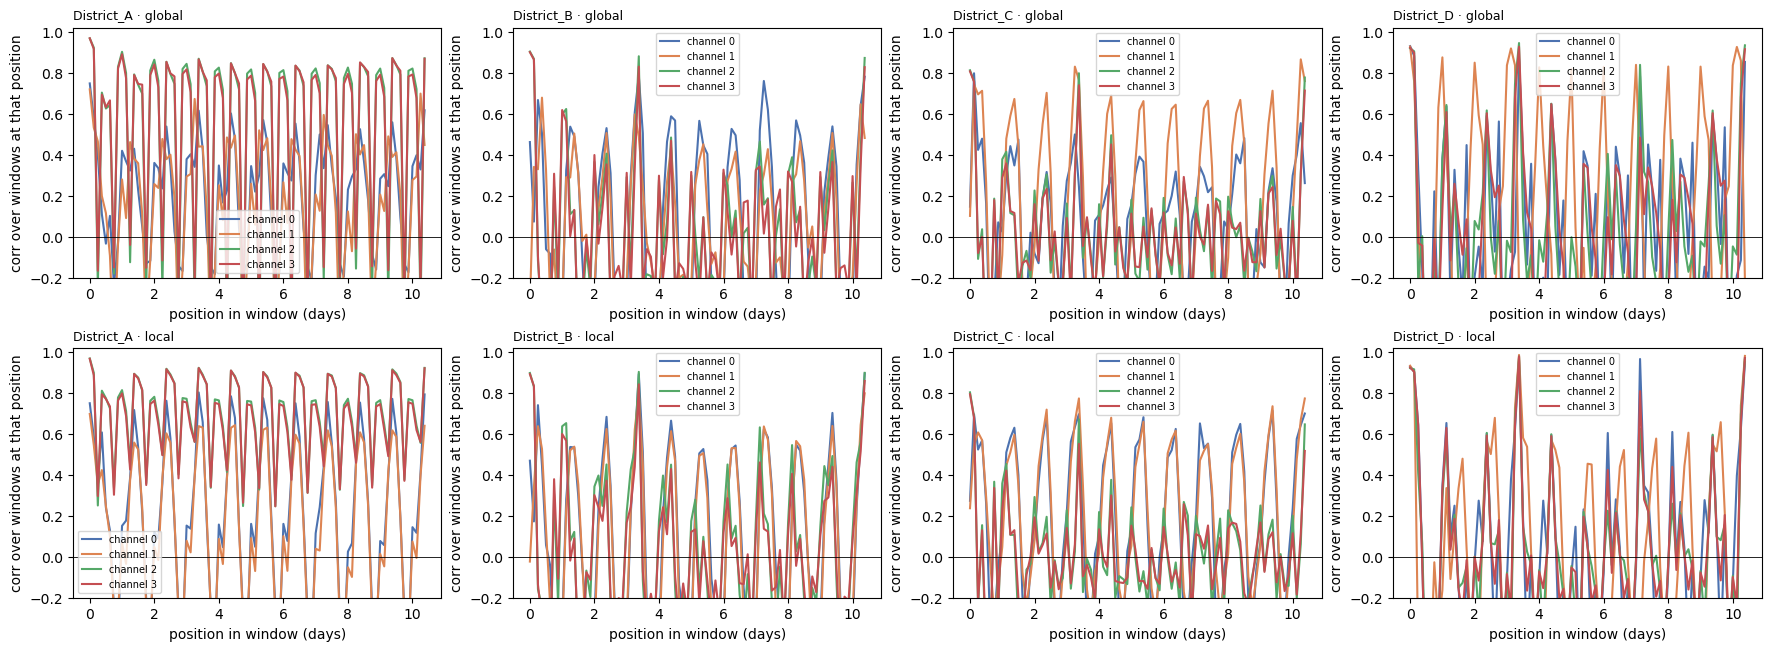

In [23]:
WS = WR.window_scores(run, fw, channels)
WS_L = pd.concat([WR.window_scores(LOCAL[c], {c: fw[c]}, channels) for c in LOCAL])
WS_C = WR.window_scores(ctrl, fw, channels)
display(pd.concat({"global": WS.groupby(["client", "slot_class"])[["r", "amp", "rmse"]].median(),
                   "local": WS_L.groupby(["client", "slot_class"])[["r", "amp", "rmse"]].median(),
                   "untrained": WS_C.groupby(["client", "slot_class"])[["r", "amp", "rmse"]].median()},
                  axis=1).round(3))

clients = world.client_names
fig, axes = plt.subplots(2, len(clients), figsize=(4.4 * len(clients), 8), squeeze=False,
                         layout="constrained")
for j, c in enumerate(clients):
    for i, cls in enumerate(("pure", "mixed")):
        im = WR.plot_score_grid(axes[i, j], WS, c, "r", cls)
fig.colorbar(im, ax=axes, shrink=0.6, label="median r (global)")
plt.show()

fig, axes = plt.subplots(2, len(clients), figsize=(4.4 * len(clients), 6.4), squeeze=False,
                         layout="constrained")
for j, c in enumerate(clients):
    WR.plot_step_profile(axes[0, j], WR.step_profile(run, fw, c), run.agg_h, title=f"{c} · global")
    WR.plot_step_profile(axes[1, j], WR.step_profile(LOCAL[c], {c: fw[c]}, c), run.agg_h,
                         title=f"{c} · local")
plt.show()

**5c. Browser.** This shows one client's windows under its **local** model, with the
**global** reconstruction overlaid (dashed), plus the overlap-add timeline of the local model.
Pick the client in `BROWSE`.

In [ ]:
BROWSE = "District_B"
_ = WR.window_browser(LOCAL[BROWSE], {BROWSE: fw[BROWSE]},
                      WS_L[WS_L["client"] == BROWSE], channels,
                      ctrl=run, ctrl_label="global model", run_label="local model")

## 6. Weekday × hour prototypes

The key is $P = 168$ h with no bin. With a 36 h stride, start positions take exactly 14 values,
one per weekday × {00h, 12h}. Every window is 10.5 days long, so every window contains a
weekend. The class fixes *where* the weekend sits in the window, which is why averaging within
a class keeps the weekly shape. Classes are pooled per phase (`block="phase"`): about 5
windows per class in init, and very few in this world's one-month `final`.

In the browser, use `period = init` to see each class's decoded prototype against its aligned
true mean, and `all cycle positions` to see all 14 classes at once.

phase,init,transition,final
cycle,,,
d0·00h,4.0,18.0,NaN
d0·12h,4.0,17.0,NaN
d1·00h,4.0,17.0,1.0
d1·12h,4.0,18.0,NaN
d2·00h,4.0,17.0,NaN
d2·12h,4.0,17.0,1.0
d3·00h,4.0,18.0,NaN
d3·12h,4.0,17.0,NaN
d4·00h,4.0,17.0,NaN


,source,phase,rmse,r_shape,amp,r2_dem,n
0,true,init,0.000,1.000,1.000,0.731,224
1,true,transition,0.000,1.000,1.000,0.766,224
2,true,final,0.000,1.000,1.000,0.700,64
3,aligned,init,0.415,0.636,0.661,0.736,224
4,aligned,transition,0.393,0.527,0.645,0.584,224
5,aligned,final,0.433,0.475,0.552,0.558,64
6,ceiling,init,0.415,0.636,0.660,0.736,224
7,ceiling,transition,0.380,0.568,0.620,0.612,224
8,ceiling,final,0.433,0.475,0.552,0.558,64
9,pooled,init,0.411,0.638,0.697,0.736,224


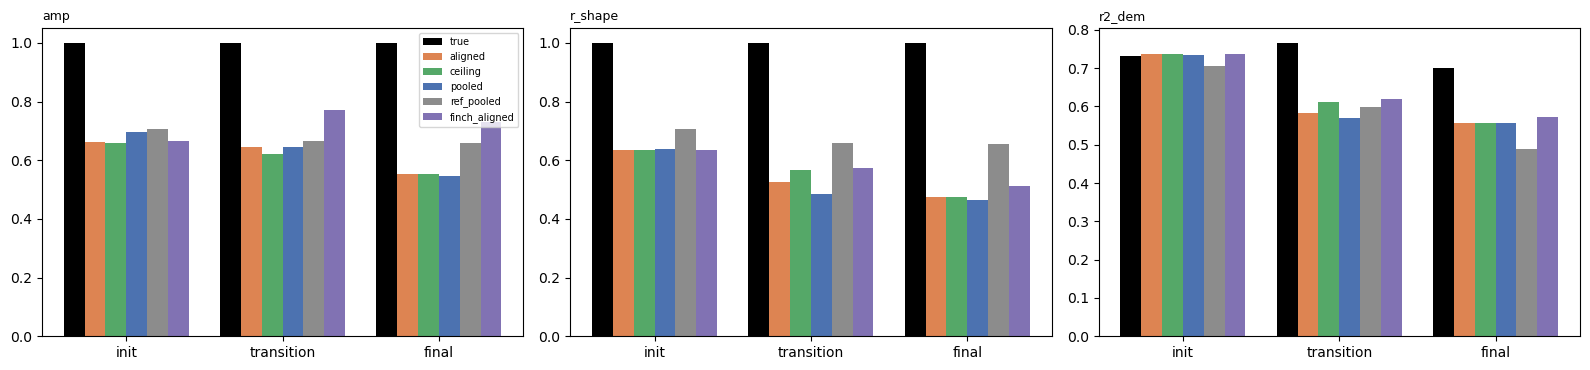

In [25]:
ALIGN168 = AL.Alignment(period_h=168, bin_h=None, block="phase")
OUT168 = AL.analyse(world, spec_f, ALIGN168, store=store, server=True, n_perm=99)
assert OUT168["checks"]["passed"].all()
cov = OUT168["coverage"]
display(cov.pivot_table(index="cycle", columns="phase", values="n_min")
           .reindex(columns=[p for p in RC.PERIODS if p in set(cov["phase"])]))
display(OUT168["summary"].round(3))
fig, ax = plt.subplots(1, 3, figsize=(16, 3.8))
AL.plot_ladder_summary(ax, OUT168["summary"])
fig.tight_layout()
plt.show()

In [26]:
_ = AL.aligned_browser(OUT168["run"], OUT168["fid"], channels)

## 7. Invariance across blocks

For each client, class $g$ (weekday·hour), block $b$ (6 months within a phase) and channel $i$,
the block is compared with the **init** reference of the same class. The reference leaves out
the block's own months when the block lies inside init.

* `r_true` $=\mathrm{corr}_t(T_{b,g,i}, T_{ref,g,i})$ and `lvl_true`: does the *data* keep
  the class shape and level? This is the target, independent of any model.
* `d_lat` $= 1-\cos(z_{b,g}, z_{ref,g})$ and `e_lat` $=\lVert z_{b,g}-z_{ref,g}\rVert /
  \lVert z_{ref,g}\rVert$: does the *representation* move? Read these trained **against
  untrained**.
* `r_dec` $=\mathrm{corr}_t(\hat T_{b,g,i}, \hat T_{ref,g,i})$ on decoded mean latents, and
  `r_fid` $=\mathrm{corr}_t(\hat T_{b,g,i}, T_{b,g,i})$: does the decoded class move with the
  data, and does it look like it at all?

**Expected on this world:**
* pure channels of B, C and D stay at `r_true` ≈ 1;
* A departs through the transition;
* mixed channels that listen to A depart in proportion to their A weight.

With about 0.4 windows per class per month, a 6-month block holds about 2.6 windows per class,
so single cells are noisy and the summaries average over classes and channels.

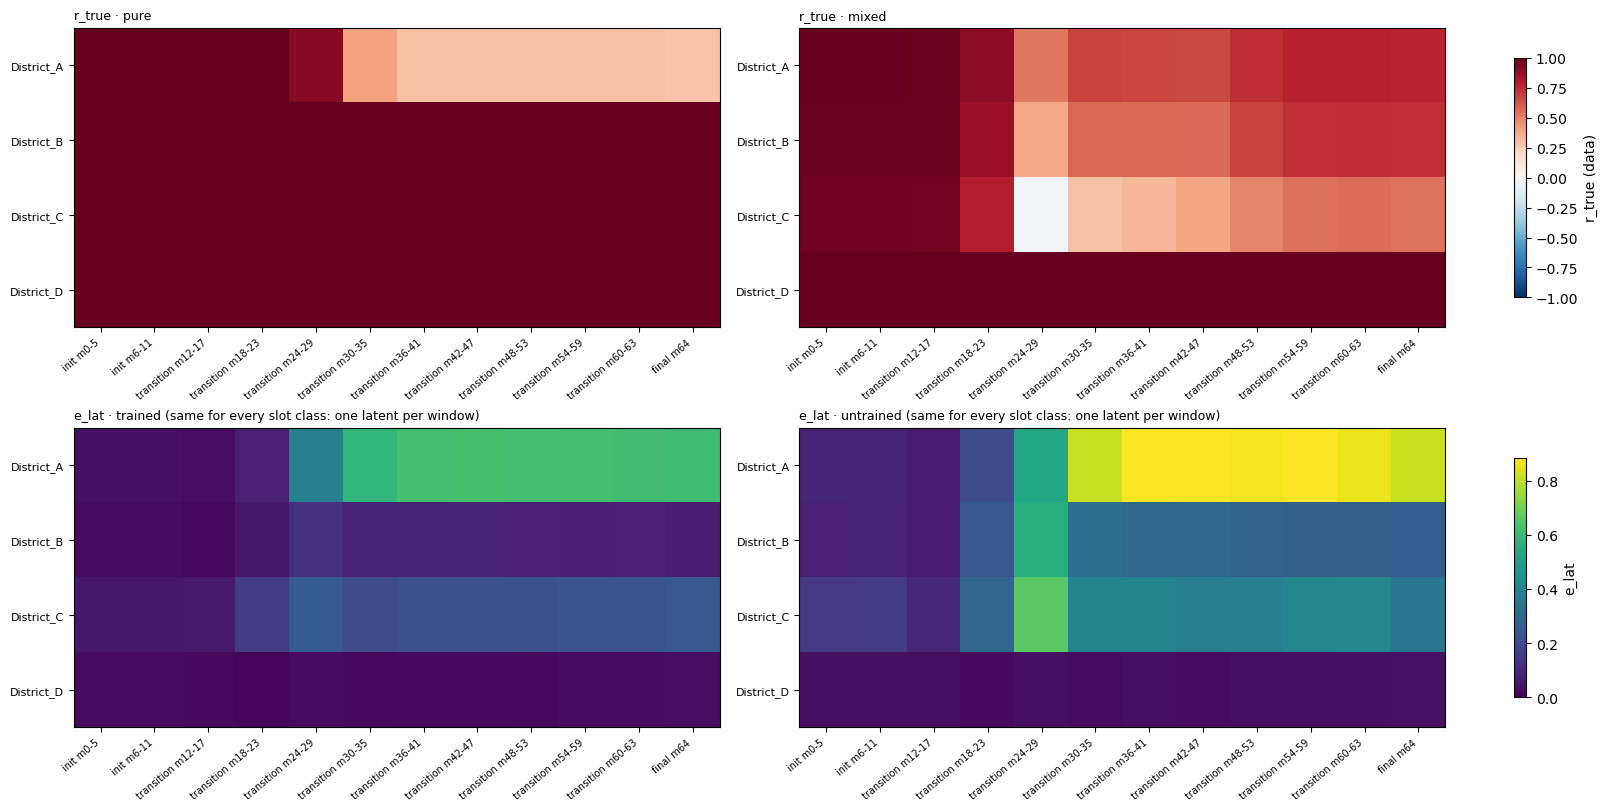

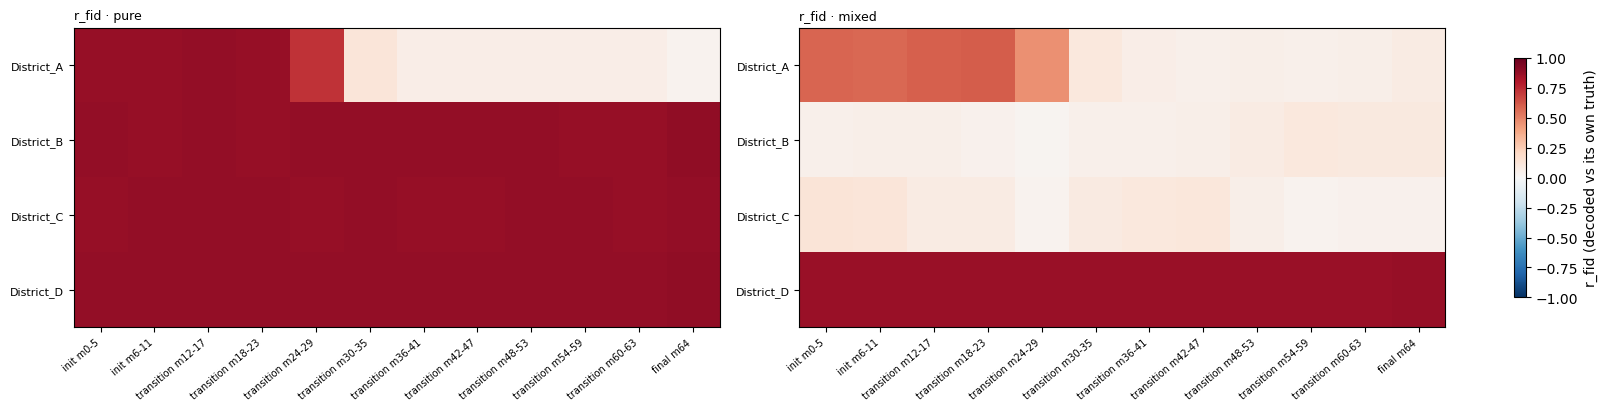

e_lat                    r_dec                    r_fid                   r_true                  
phase                  final   init transition  final   init transition  final   init transition  final   init transition
client     slot_class                                                                                                    
District_A mixed       0.612  0.038      0.467  0.155  1.000      0.427  0.085  0.580      0.228  0.761  0.986      0.742
           pure        0.612  0.038      0.467  0.145  1.000      0.444  0.033  0.875      0.325  0.286  0.994      0.530
District_B mixed       0.076  0.024      0.079  0.998  1.000      0.998  0.099  0.054      0.065  0.729  0.982      0.677
           pure        0.076  0.024      0.079  1.000  1.000      1.000  0.886  0.876      0.875  0.995  0.996      0.997
District_C mixed       0.246  0.057      0.201  0.946  0.998      0.968  0.045  0.124      0.072  0.547  0.970      0.481
           pure        0.246  0.057      0.201  0.997  1.000      0.998  0.881  0.875      0.875  0.995  0.994      0.996
District_D mixed       0.028  0.026      0.022  1.000  1.000      1.000  0.873  0.866      0.865  0.999  0.998      0.999
           pure        0.028  0.026      0.022  1.000  1.000      1.000  0.886  0.878      0.878  0.999  0.998      0.999

In [17]:
BLOCK = 6
INV = AL.invariance(world, run.wt, fw, model, channels, block=BLOCK)
INV_C = AL.invariance(world, ctrl.wt, fw, None, channels, block=BLOCK)
S_T, S_C = AL.invariance_summary(INV), AL.invariance_summary(INV_C)

fig, axes = plt.subplots(2, 2, figsize=(16, 8), layout="constrained")
for j, cls in enumerate(("pure", "mixed")):
    im = AL.plot_invariance(axes[0, j], S_T, "r_true", cls, vmin=-1, vmax=1)
fig.colorbar(im, ax=axes[0], shrink=0.8, label="r_true (data)")
vmax = float(np.nanpercentile(pd.concat([S_T["e_lat"], S_C["e_lat"]]), 98))
for j, (name, S) in enumerate((("trained", S_T), ("untrained", S_C))):
    im = AL.plot_invariance(axes[1, j], S, "e_lat", "pure", vmin=0, vmax=vmax,
                            cmap="viridis")
    axes[1, j].set_title(f"e_lat · {name} (same for every slot class: one latent "
                         "per window)", fontsize=9, loc="left")
fig.colorbar(im, ax=axes[1], shrink=0.8, label="e_lat")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 4), layout="constrained")
for j, cls in enumerate(("pure", "mixed")):
    im = AL.plot_invariance(axes[j], S_T, "r_fid", cls, vmin=-1, vmax=1)
fig.colorbar(im, ax=axes, shrink=0.8, label="r_fid (decoded vs its own truth)")
plt.show()

display(S_T.pivot_table(index=["client", "slot_class"], columns="phase",
                        values=["r_true", "r_dec", "r_fid", "e_lat"])
           .round(3))

## 8. Latent diagnostics of the focus cell

These are the §8 tables of the first run for this cell: loss by round, the loss against flat
baselines, decoder levels, η² per snapshot round (round −1 = control), and the spread per
round.

In [18]:
for k in ("loss", "baselines"):
    display(san[k].round(4))
display(san["levels"].groupby(["client", "phase"])[["level_r", "level_ratio", "shape_amp"]]
          .mean().round(3))
display(san["eta"].pivot_table(index=["round", "stage"], columns="phase", values="lift",
                               sort=False).round(3))
display(san["spread"].round(4))

,round,loss,loss_mse,loss_proto,d_mse,aux_share
0,0,0.8376,0.3432,0.0000,NaN,0.5903
1,1,0.9045,0.3252,0.8509,-0.0523,0.6404
2,2,0.8723,0.2939,0.8475,-0.0963,0.6631
3,3,0.8436,0.2678,0.8331,-0.0888,0.6825
4,4,0.8338,0.2616,0.8242,-0.0234,0.6863
5,5,0.7443,0.2417,0.8132,-0.0758,0.6753
6,6,0.6311,0.2187,0.8435,-0.0950,0.6534
7,7,0.8557,0.2721,0.8206,0.2438,0.6820
8,8,0.8237,0.2556,0.8298,-0.0605,0.6897
9,9,0.8099,0.2505,0.8201,-0.0199,0.6907


,client,n,loss_final,base_const,base_wmean,final_over_const,final_over_wmean
0,District_A,387,0.1940,0.4460,0.2646,0.4349,0.7331
1,District_B,387,0.1857,0.2947,0.2936,0.6304,0.6326
2,District_C,387,0.2362,0.3282,0.3142,0.7198,0.7518
3,District_D,387,0.1027,0.3300,0.3299,0.3113,0.3113


level_r  level_ratio  shape_amp
client     phase                                      
District_A final         0.529        4.107      0.057
           init          0.403        7.192      0.660
           transition    0.830        1.193      0.083
District_B final         0.630        3.143      0.617
           init          0.372        3.738      0.594
           transition    0.225        1.744      0.599
District_C final         0.432        1.822      0.591
           init          0.652        4.227      0.609
           transition    0.402        2.191      0.587
District_D final         0.726        3.539      0.631
           init          0.248        4.314      0.629
           transition    0.285        4.057      0.629

phase              all  final   init  transition
round     stage                                 
-1        pre    0.272  0.239  0.437       0.235
0         pre    0.256  0.175  0.432       0.217
          post   0.268  0.218  0.427       0.232
14        pre    0.287  0.205  0.441       0.253
          post   0.286  0.215  0.436       0.252
29        pre    0.350  0.248  0.460       0.326
          post   0.325  0.223  0.428       0.303
final_all post   0.336  0.223  0.440       0.314

,round,stage,n,norm,s_client,s_block,s_group,rel_block
0,-1,pre,1296,0.0849,0.0329,0.0274,0.0187,0.3228
1,0,post,1296,0.1118,0.0394,0.0317,0.0219,0.2834
2,0,pre,1296,0.1407,0.0575,0.0379,0.0269,0.2691
3,14,post,1296,0.4524,0.0970,0.0560,0.0393,0.1238
4,14,pre,1296,0.4530,0.1027,0.0575,0.0404,0.1269
5,29,post,1296,0.5137,0.1026,0.0701,0.0458,0.1365
6,29,pre,1296,0.5172,0.1183,0.0713,0.0453,0.1378
7,final_all,post,1548,0.5135,0.1029,0.0720,0.0486,0.1401


## What this leaves open

* **Evaluation is in-sample.** FL trains on every month. A held-out-month evaluation of the
  local and global models (POC_03's purged split applied inside FL) is the next step before
  selecting cells.
* **Orientation does not remove bidirectional sensors.** Their sign is information, not
  convention. If they remain the weak channels, they need their own encoding (magnitude plus
  direction).

* **The decoder design.** The decoder receives the same latent vector at every step. In the
  harness, an undertrained decoder reproduces the first few steps and then settles to a
  constant, as an LSTM driven by constant input tends to do. If `long` still shows that shape
  in §5, the next axis is the architecture: feed the decoder a per-step time or phase encoding
  alongside $z$. That is an upstream `AER` change.
* **The drift window is short.** `final` is one month in this world, so the final side of §6
  and §7 rests on the transition blocks.
* **GPU equivalence.** `long·up pw0` and `long·lab pw0` are equivalent by construction and
  bit-identical on CPU (§2a). On GPU, compare them on the metrics.
* **Loss weights.** The loss-term weights are first guesses ($\lambda = 1$, $\gamma = 0.1$).
  Read §3 before sweeping them.